## Problem specification

Set up a micromagnetic model of a thin magnetic film with controllable:
- Anisotropy direction (in-plane, out-of-plane, or mixed)
- Anisotropy strength
- Applied field direction and magnitude

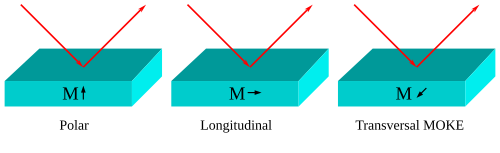

In [1]:
import discretisedfield as df
import micromagneticmodel as mm
import oommfc as mc
import numpy as np
import mammos_units as u
import mammos_entity as me
import mammos_analysis
import matplotlib.pyplot as plt
u.set_enabled_equivalencies(u.magnetic_flux_field());

Now, we can set all required geometry and material parameters.

In [3]:
# Geometry
lx = 300e-9  # x dimension of the sample(m)
ly = 300e-9  # y dimension of the sample (m)
lz = 10e-9  # sample thickness (m)

# Material (permalloy) parameters
Ms = 8e5  # saturation magnetisation (A/m)
A = 1.3e-11  # exchange energy constant (J/m)
K = 1e6 # uniaxial anisotropy constant (J/m^3)

In [5]:
cell = (5e-9, 5e-9, 5e-9)  # mesh discretisation (m)
mesh = df.Mesh(p1=(0, 0, 0), p2=(lx, ly, lz), cell=cell)  # Create a mesh object.

In [6]:
mesh.pyvista()

Dropped Escape call with ulEscapeCode : 0x03007703
Dropped Escape call with ulEscapeCode : 0x03007703
Dropped Escape call with ulEscapeCode : 0x03007703


Widget(value='<iframe src="http://localhost:41293/index.html?ui=P_0x7fb22466d150_0&reconnect=auto" class="pyvi…

In [7]:
system = mm.System(name="Example")

In [8]:
system.energy = mm.Exchange(A=A) + mm.Demag() + mm.UniaxialAnisotropy(K=K, u=(0, 0, 1))

We can check what is the continuous model of system's Hamiltonian.

In [9]:
system.energy

Exchange(A=1.3e-11) + Demag() + UniaxialAnisotropy(K=1000000.0, u=(0, 0, 1))

Initalise the magnetisation to be along the easy axis of the system.

In [11]:
system.m = df.Field(mesh, nvdim=3, value=(0, 0, 1), norm=Ms)

Perform a hysteresis loop by sweeping the applied field along the hard axis of the system.

In [12]:
Hmin = (10, 0, 2 / mm.consts.mu0)
Hmax = (10, 0, -2 / mm.consts.mu0)

In [13]:
hd = mc.HysteresisDriver()
hd.drive(system, Hmin=Hmin, Hmax=Hmax, n=101)

Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:45:00]... (8.4 s)


Plot the averaged magnetisation.

In [15]:
H_z = me.H(
    system.table.data["Bz_hysteresis"].values  # simulation output in mT
    * u.Unit(system.table.units["Bz_hysteresis"]).to(u.A / u.m)  # conversion factor from mT to A/m
)
M_x = me.Entity("Magnetization", system.table.data["mx"].values * Ms)
M_y = me.Entity("Magnetization", system.table.data["my"].values * Ms)
M_z = me.Entity("Magnetization", system.table.data["mz"].values * Ms)

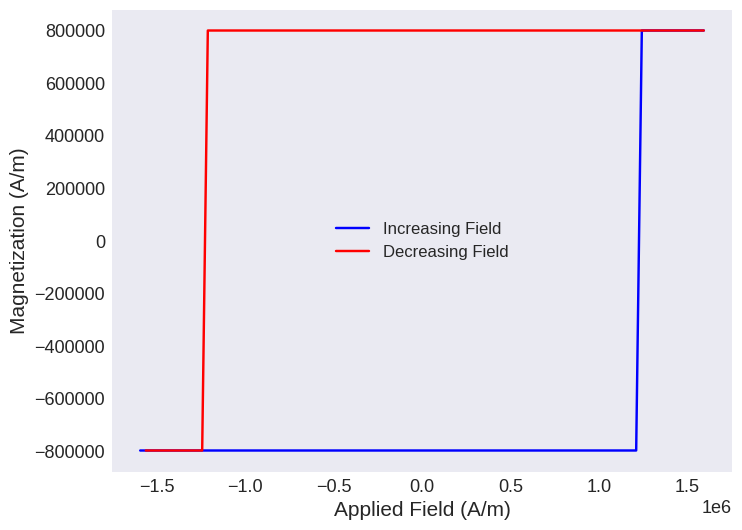

In [16]:
# Split loop into two parts for plotting
half = len(H_z.q) // 2
H_z_down = H_z.q[:half]
M_z_down = M_z.q[:half]
H_z_up = H_z.q[half:]
M_z_up = M_z.q[half:]
plt.figure(figsize=(8, 6))
plt.plot(H_z_up, M_z_up, label="Increasing Field", color="blue")
plt.plot(H_z_down, M_z_down, label="Decreasing Field", color="red")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization (A/m)")
plt.legend()

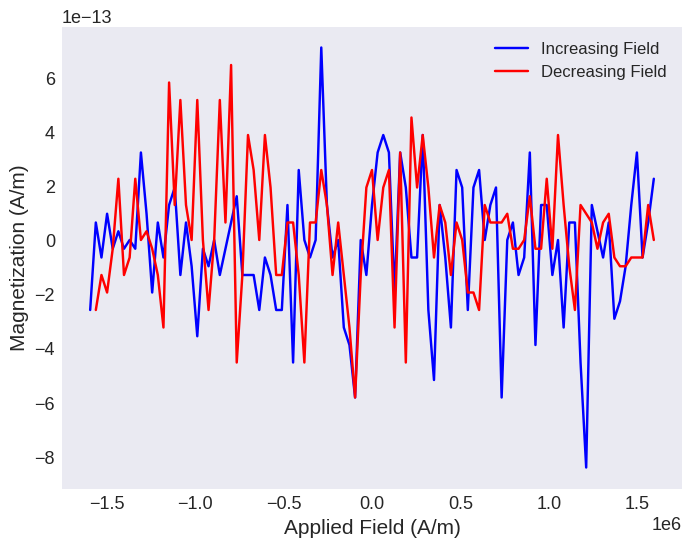

In [17]:
M_y_down = M_y.q[:half]
M_y_up = M_y.q[half:]
plt.figure(figsize=(8, 6))
plt.plot(H_z_up, M_y_up, label="Increasing Field", color="blue")
plt.plot(H_z_down, M_y_down, label="Decreasing Field", color="red")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization (A/m)")
plt.legend()

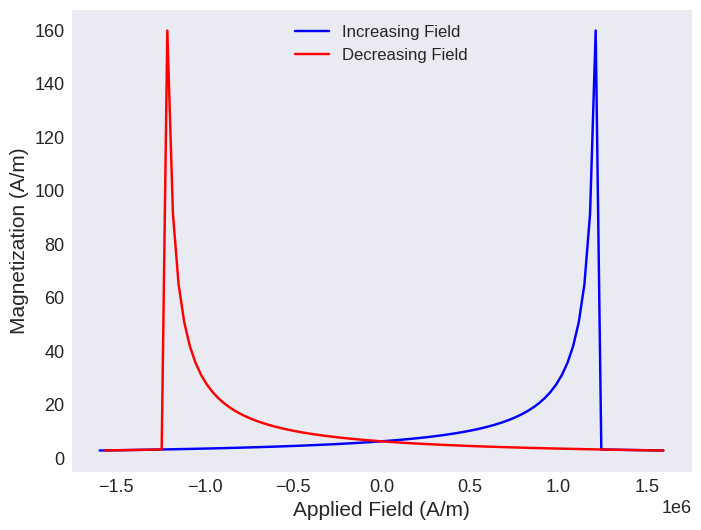

In [18]:
M_x_down = M_x.q[:half]
M_x_up = M_x.q[half:]
plt.figure(figsize=(8, 6))
plt.plot(H_z_up, M_x_up, label="Increasing Field", color="blue")
plt.plot(H_z_down, M_x_down, label="Decreasing Field", color="red")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization (A/m)")
plt.legend()

In [20]:
results = mammos_analysis.hysteresis.extrinsic_properties(H_z_up, M_z_up)
results

ExtrinsicProperties(Hc=Entity(ontology_label='CoercivityHcExternal', value=1225492.7263066757, unit='A / m'), Mr=Entity(ontology_label='Remanence', value=799978.7383223999, unit='A / m'), BHmax=Entity(ontology_label='MaximumEnergyProduct', value=nan, unit='J / m3'))

In [21]:
results.Hc

Entity(ontology_label='CoercivityHcExternal', value=1225492.7263066757, unit='A / m')

In [22]:
results.Mr

Entity(ontology_label='Remanence', value=799978.7383223999, unit='A / m')

In [23]:
results.Mr.value/Ms

0.9999734229029998

Create a function so we can easily test lots of parameters.

In [24]:
def run_loop(K, u_axis, H_axis, Hmax, n=51):
    easy_axis = np.asarray(u_axis, dtype=float)
    easy_axis /= np.linalg.norm(easy_axis)

    h = np.asarray(H_axis, dtype=float)
    h /= np.linalg.norm(h)

    system = mm.System(name="moke")
    system.energy = (
        mm.Exchange(A=A)
        + mm.Demag()
        + mm.UniaxialAnisotropy(K=K, u=easy_axis)
    )
    system.m = df.Field(mesh, nvdim=3, value=h, norm=Ms)

    hd = mc.HysteresisDriver()
    hd.drive(system, Hsteps=[
        [tuple(Hmax * h + np.array([0, 100, 0])), tuple(-Hmax * h + np.array([0, 100, 0])), n]
    ])

    Hx = (system.table.data["Bx_hysteresis"].values * u.mT).to(u.A / u.m)
    Hy = (system.table.data["By_hysteresis"].values * u.mT).to(u.A / u.m)
    Hz = (system.table.data["Bz_hysteresis"].values * u.mT).to(u.A / u.m)
    H = Hx * h[0] + Hy * h[1] + Hz * h[2]
    mx = system.table.data["mx"].values * Ms * u.A / u.m
    my = system.table.data["my"].values * Ms * u.A / u.m
    mz = system.table.data["mz"].values * Ms * u.A / u.m

    return H, Hx, Hy, Hz, mx, my, mz

In [25]:
def metrics(H, sig):
    results = mammos_analysis.hysteresis.extrinsic_properties(H, sig)
    Hc = results.Hc.q
    squareness = results.Mr.value / Ms
    return Hc, squareness

## Easy axis out of plane

In [26]:
H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[0, 0, 1], H_axis=[0, 0, 1], Hmax=(2 * u.T).to("A/m").value)

Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:49:45]... (3.1 s)


Text(0, 0.5, 'Magnetization Mz (A/m)')

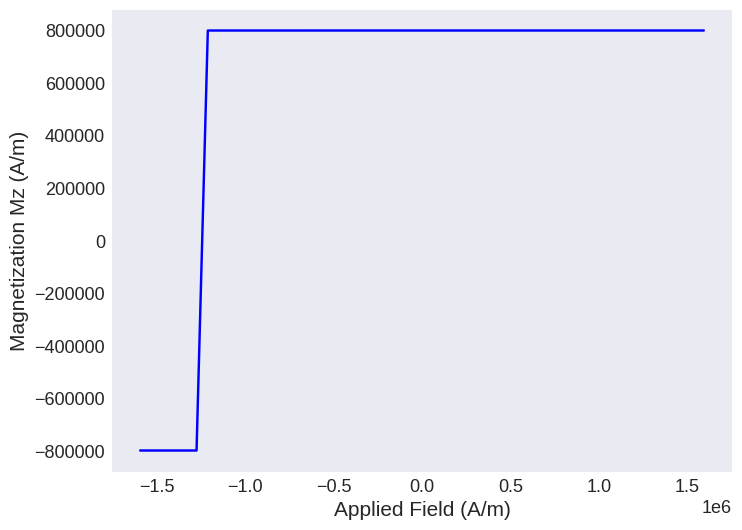

In [27]:
# Polar MOKE
plt.plot(H, mz, label="mz", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")

Text(0, 0.5, 'Magnetization Mx(A/m)')

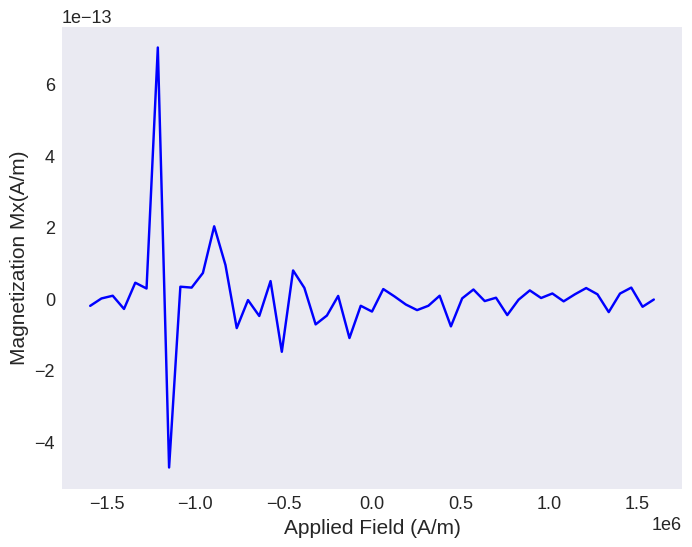

In [28]:
# Longitudinal MOKE
plt.plot(H, mx, label="mx", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mx(A/m)")

Text(0, 0.5, 'Magnetization My(A/m)')

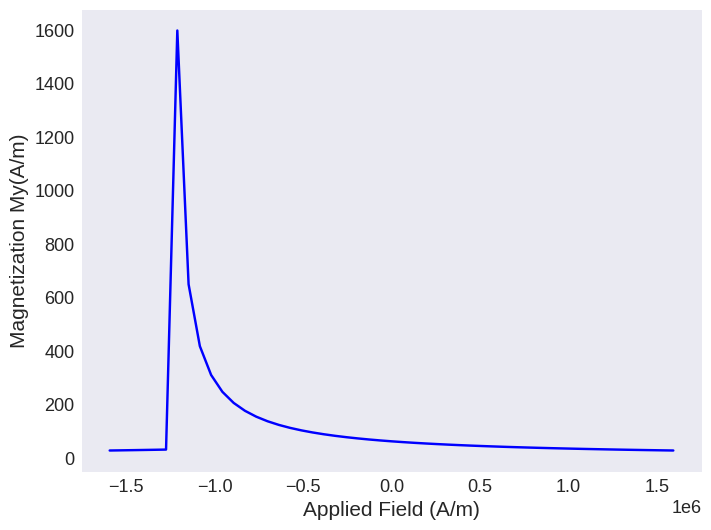

In [29]:
plt.plot(H, my, label="my", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization My(A/m)")

In [30]:
metrics(H, mz)  # Polar MOKE

(<Quantity 1241407.84255198 A / m>, 0.999973419911)

## Easy axis along y direction

In [31]:
H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[0, 1, 0], H_axis=[0, 0, 1], Hmax=(4 * u.T).to("A/m").value)

Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:49:58]... (4.4 s)


Text(0, 0.5, 'Magnetization Mz (A/m)')

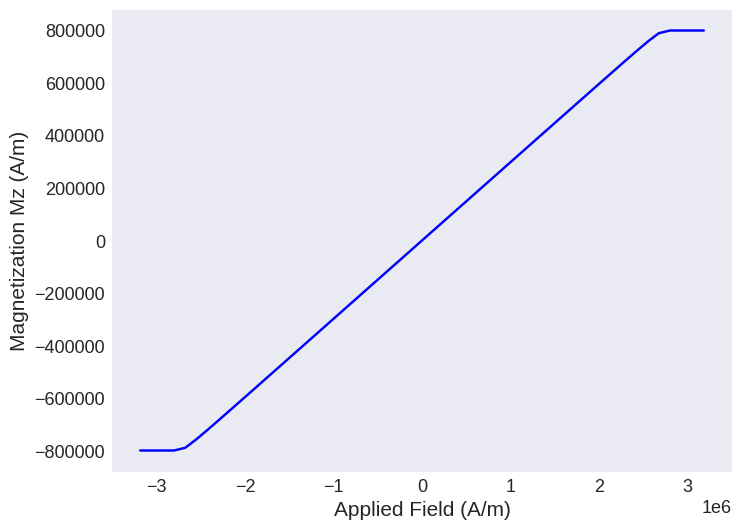

In [32]:
# Polar MOKE
plt.plot(H, mz, label="mz", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")

Text(0, 0.5, 'Magnetization Mx(A/m)')

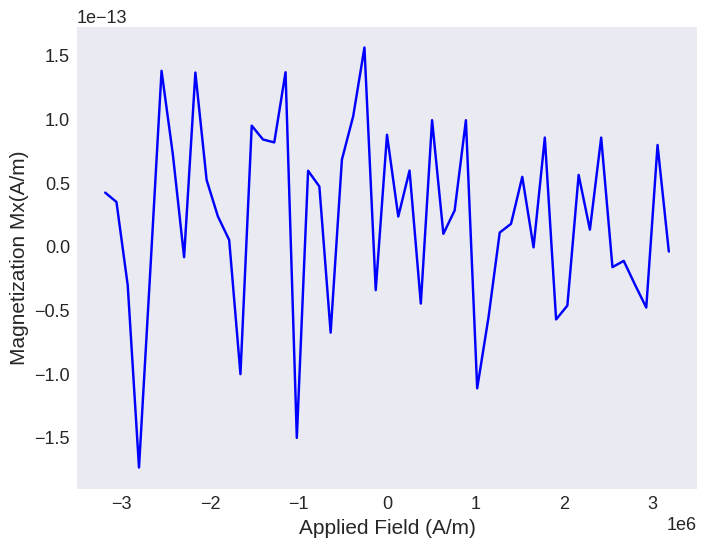

In [41]:
# Longitudinal MOKE
plt.plot(H, mx, label="mx", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mx(A/m)")

Text(0, 0.5, 'Magnetization My (A/m)')

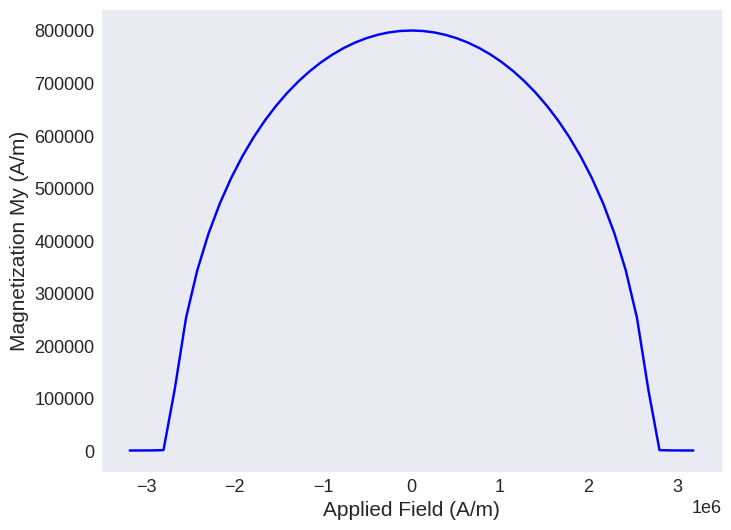

In [42]:
# Longitudinal MOKE
plt.plot(H, my, label="my", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization My (A/m)")

## Easy axis in x direction

In [43]:
H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[1, 0, 0], H_axis=[0, 0, 1], Hmax=(4 * u.T).to("A/m").value)

Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:49:13]... (7.9 s)


Text(0, 0.5, 'Magnetization Mx(A/m)')

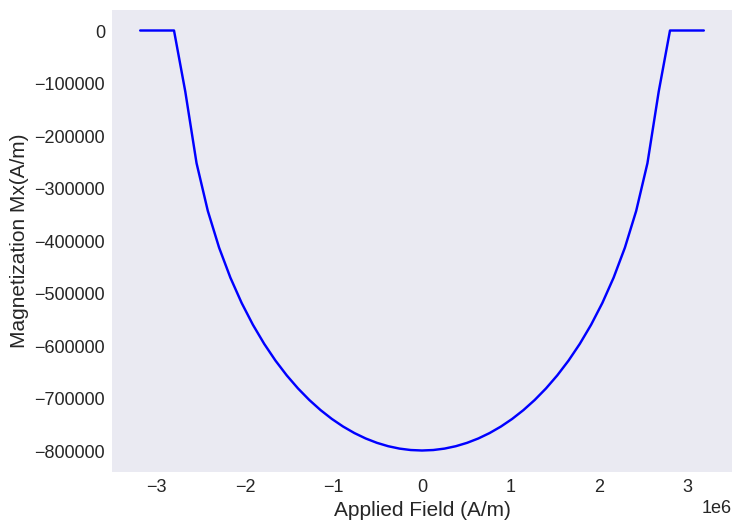

In [44]:
# Longitudinal MOKE
plt.plot(H, mx, label="mx", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mx(A/m)")


Text(0, 0.5, 'Magnetization My (A/m)')

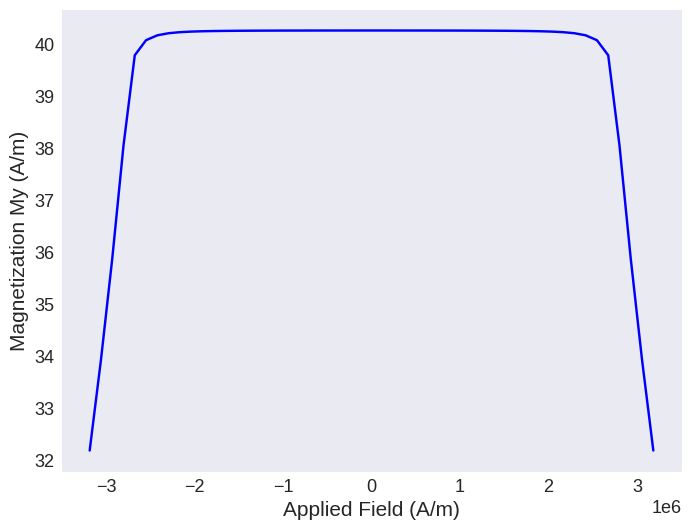

In [45]:
# Longitudinal MOKE
plt.plot(H, my, label="my", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization My (A/m)")

Text(0, 0.5, 'Magnetization Mz (A/m)')

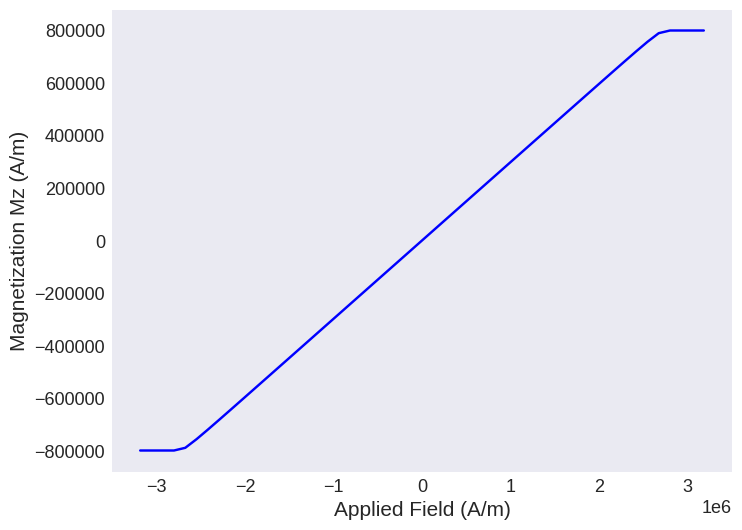

In [46]:
# Polar MOKE
plt.plot(H, mz, label="mz", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")

## Easy axis along [0, 1, 2] direction

In [47]:
H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[0, 1, 2], H_axis=[0, 0, 1], Hmax=(4 * u.T).to("A/m").value)


Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:49:57]... (2.8 s)


Text(0, 0.5, 'Magnetization Mz (A/m)')

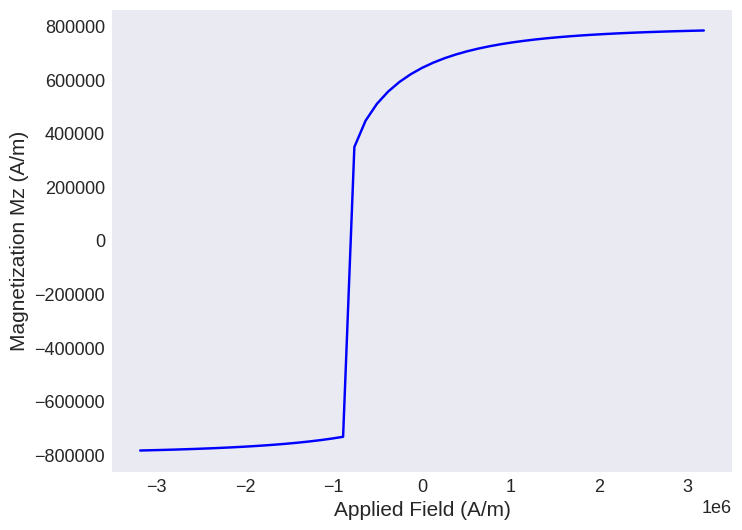

In [48]:
# Polar MOKE
plt.plot(H, mz, label="mz", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")

Text(0, 0.5, 'Magnetization Mx(A/m)')

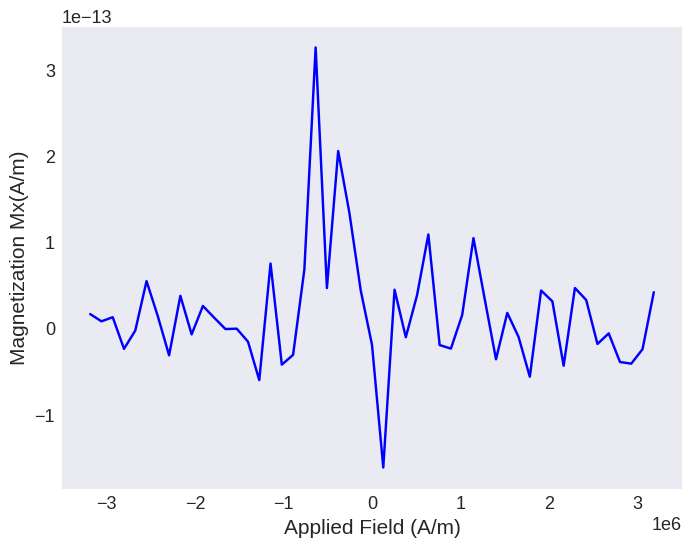

In [49]:
# Longitudinal MOKE
plt.plot(H, mx, label="mx", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mx(A/m)")

Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:50:31]... (2.9 s)


Text(0, 0.5, 'Magnetization Mz (A/m)')

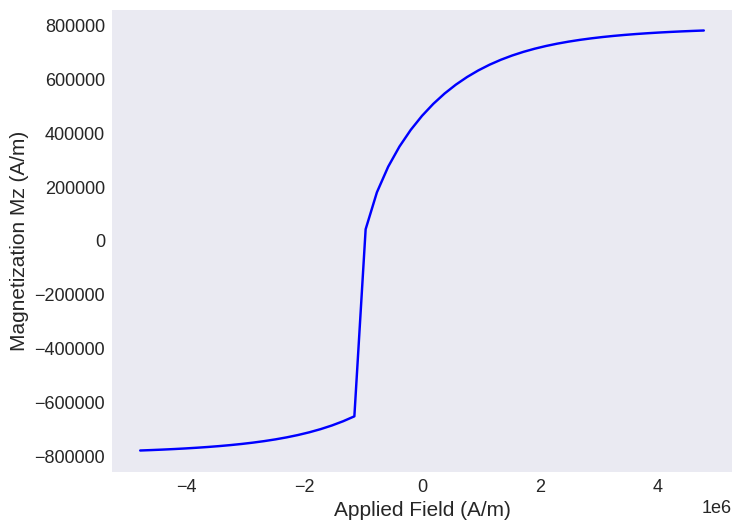

In [54]:
H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[0, 1, 1], H_axis=[0, 0, 1], Hmax=(6 * u.T).to("A/m").value)
# Polar MOKE
plt.plot(H, mz, label="mz", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")

In [55]:
metrics(H, mz)

(<Quantity 966414.27163287 A / m>, 0.57901098838)

Text(0, 0.5, 'Magnetization Mx(A/m)')

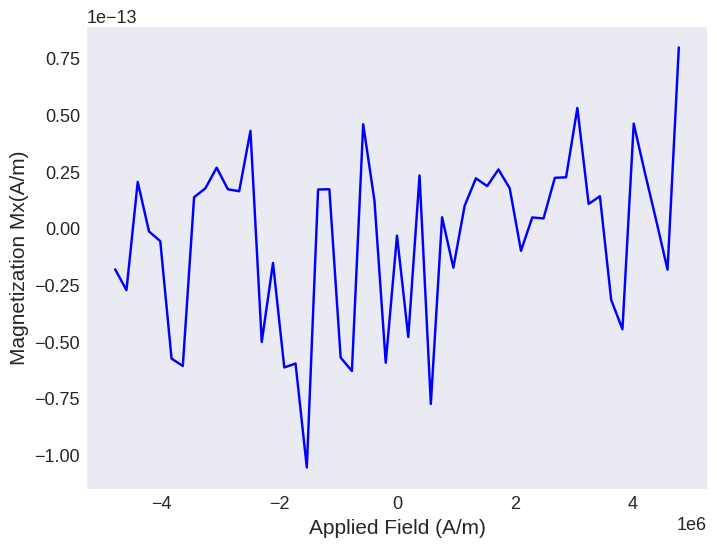

In [56]:
# Longitudinal MOKE
plt.plot(H, mx, label="mx", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mx(A/m)")

Text(0, 0.5, 'Magnetization My(A/m)')

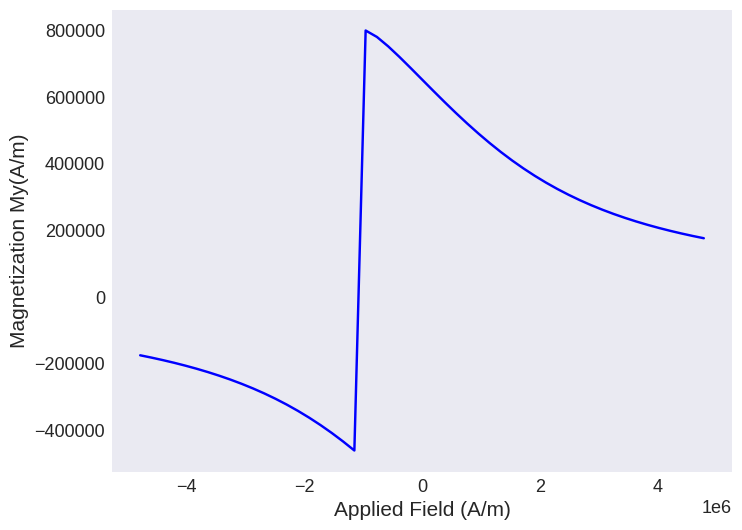

In [57]:
plt.plot(H, my, label="my", color="blue")
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization My(A/m)")

A false negative happens whenever the MOKE sensitivity axis is perpendicular to the easy axis

## Minor loop investigation

Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:13]... (2.7 s)
Bmax = 0.30 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:16]... (2.7 s)
Bmax = 0.50 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:19]... (2.9 s)
Bmax = 0.75 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:22]... (3.2 s)
Bmax = 1.00 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:25]... (3.3 s)
Bmax = 1.50 T  ->  Hc = 8.250e+05 A / m, squareness = 0.81  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:28]... (3.2 s)
Bmax = 2.00 T  ->  Hc = 8.436e+05 A / m, squareness = 0.81  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:31]... (3.0 s)
Bmax = 4.00 T  ->  Hc = 8.050e+05 A / m, squareness = 0.81  (detected hard)


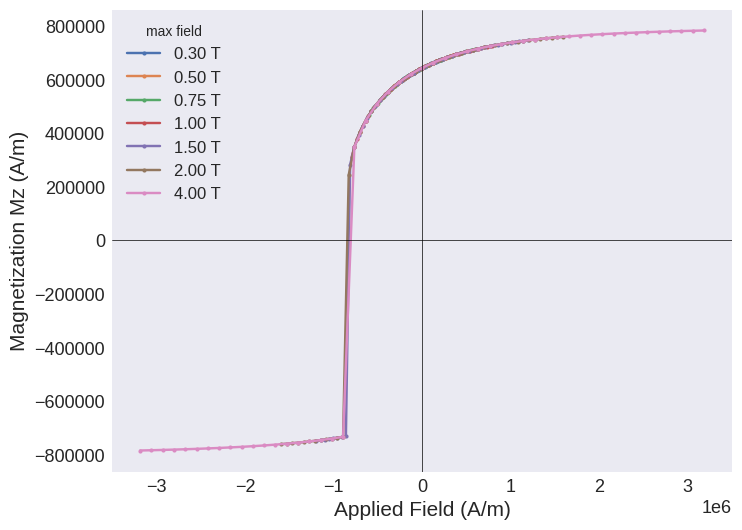

In [58]:
Bmax_values = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]  # Tesla

plt.figure(figsize=(8, 6))
for Bmax in Bmax_values:
    Hmax = (Bmax * u.T).to("A/m").value
    H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[1, 0, 2], H_axis=[0, 0, 1], Hmax=Hmax)
    try:
        Hc, squareness = metrics(H, mz)  # Polar MOKE
        print(f"Bmax = {Bmax:.2f} T  ->  Hc = {Hc:.3e}, squareness = {squareness:.2f}  (detected hard)")
    except ValueError:
        print(f"Bmax = {Bmax:.2f} T  ->  no switching: FALSE NEGATIVE")
    plt.plot(H, mz, marker="o", ms=3, label=f"{Bmax:.2f} T")

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")
plt.legend(title="max field")


Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:35]... (2.1 s)
Bmax = 0.30 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:37]... (2.3 s)
Bmax = 0.50 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:39]... (2.3 s)
Bmax = 0.75 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:41]... (2.3 s)
Bmax = 1.00 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:44]... (3.0 s)
Bmax = 1.50 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:47]... (3.4 s)
Bmax = 2.00 T  ->  Hc = 1.241e+06 A / m, squareness = 1.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T16:51:50]... (3.5 s)
Bmax = 4.00 T  ->  Hc = 1.210e+06 A / m, squareness = 1.00  (detected hard)


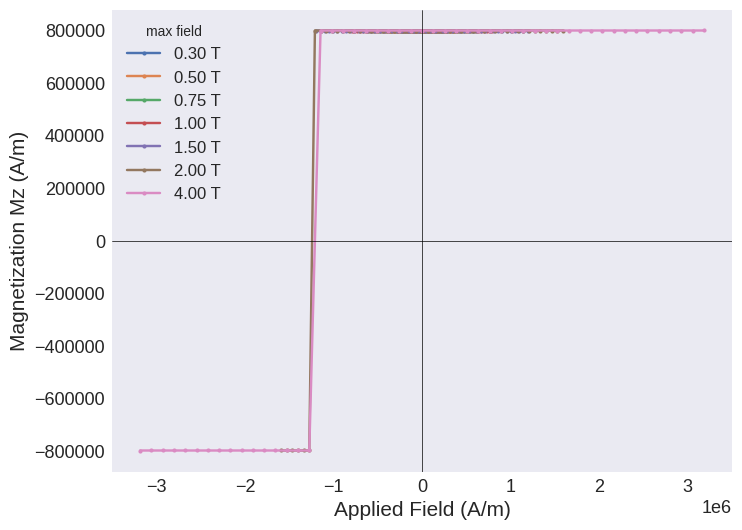

In [59]:
Bmax_values = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]  # Tesla

plt.figure(figsize=(8, 6))
for Bmax in Bmax_values:
    Hmax = (Bmax * u.T).to("A/m").value
    H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[0, 0, 1], H_axis=[0, 0, 1], Hmax=Hmax)
    try:
        Hc, squareness = metrics(H, mz)  # Polar MOKE
        print(f"Bmax = {Bmax:.2f} T  ->  Hc = {Hc:.3e}, squareness = {squareness:.2f}  (detected hard)")
    except ValueError:
        print(f"Bmax = {Bmax:.2f} T  ->  no switching: FALSE NEGATIVE")
    plt.plot(H, mz, marker="o", ms=3, label=f"{Bmax:.2f} T")

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")
plt.legend(title="max field")


Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:51:39]... (9.9 s)
Bmax = 0.30 T  ->  Hc = 8.234e-07 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:51:49]... (11.2 s)
Bmax = 0.50 T  ->  Hc = 3.964e-04 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:52:01]... (15.3 s)
Bmax = 0.75 T  ->  Hc = 2.062e-05 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:52:16]... (14.8 s)
Bmax = 1.00 T  ->  Hc = 1.832e+03 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:52:31]... (13.8 s)
Bmax = 1.50 T  ->  Hc = 1.831e+03 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:52:45]... (24.8 s)
Bmax = 2.00 T  ->  Hc = 1.159e-04 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:53:09]... (5.9 s)
Bmax = 4.00 T  ->  Hc = 2.345e-03 A / m, squareness = 0.00  (detected hard)


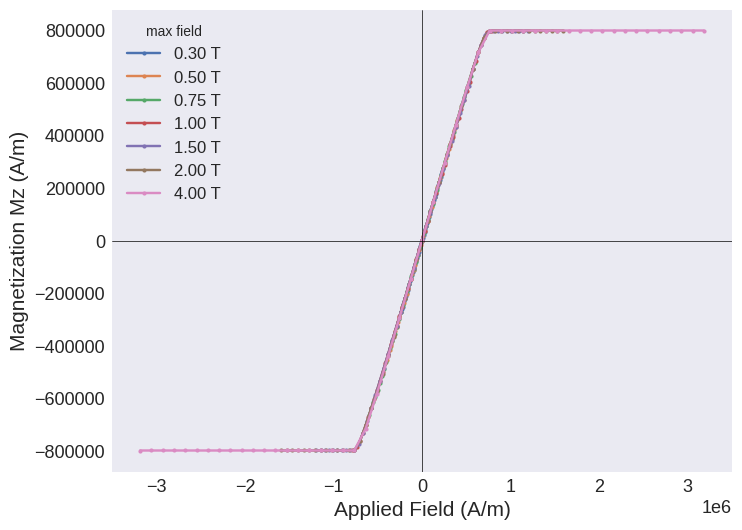

In [33]:
Bmax_values = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]  # Tesla

plt.figure(figsize=(8, 6))
for Bmax in Bmax_values:
    Hmax = (Bmax * u.T).to("A/m").value
    H, Hx, Hy, Hz, mx, my, mz = run_loop(K=0, u_axis=[1, 0, 0], H_axis=[0, 0, 1], Hmax=Hmax)
    try:
        Hc, squareness = metrics(H, mz)  # Polar MOKE
        print(f"Bmax = {Bmax:.2f} T  ->  Hc = {Hc:.3e}, squareness = {squareness:.2f}  (detected hard)")
    except ValueError:
        print(f"Bmax = {Bmax:.2f} T  ->  no switching: FALSE NEGATIVE")
    plt.plot(H, mz, marker="o", ms=3, label=f"{Bmax:.2f} T")

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")
plt.legend(title="max field")

Running OOMMF (ExeOOMMFRunner)[2026-06-25T18:00:39]... (3.4 s)
Bmax = 0.30 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T18:00:43]... (3.0 s)
Bmax = 0.50 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T18:00:46]... (3.0 s)
Bmax = 0.75 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T18:00:49]... (3.0 s)
Bmax = 1.00 T  ->  no switching: FALSE NEGATIVE
Running OOMMF (ExeOOMMFRunner)[2026-06-25T18:00:52]... (3.3 s)
Bmax = 1.50 T  ->  Hc = 8.250e+05 A / m, squareness = 0.81  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T18:00:55]... (3.2 s)
Bmax = 2.00 T  ->  Hc = 8.436e+05 A / m, squareness = 0.81  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T18:00:58]... (2.9 s)
Bmax = 4.00 T  ->  Hc = 8.050e+05 A / m, squareness = 0.81  (detected hard)


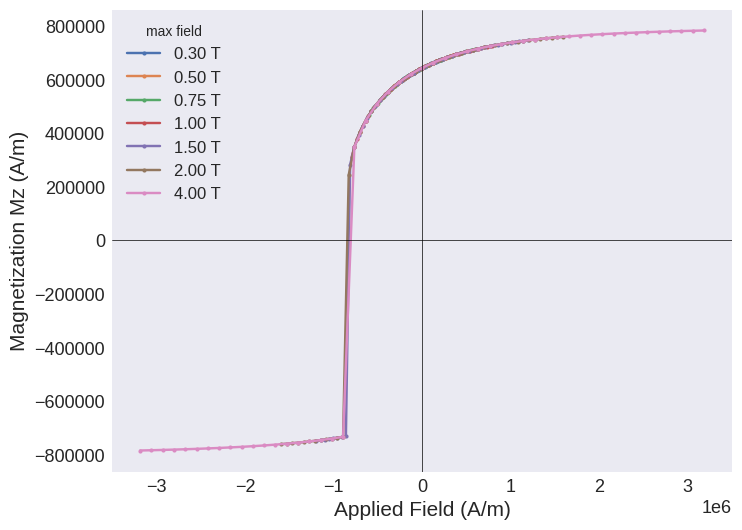

In [37]:
Bmax_values = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]  # Tesla

plt.figure(figsize=(8, 6))
for Bmax in Bmax_values:
    Hmax = (Bmax * u.T).to("A/m").value
    H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[1, 0, 2], H_axis=[0, 0, 1], Hmax=Hmax)
    try:
        Hc, squareness = metrics(H, mz)  # Polar MOKE
        print(f"Bmax = {Bmax:.2f} T  ->  Hc = {Hc:.3e}, squareness = {squareness:.2f}  (detected hard)")
    except ValueError:
        print(f"Bmax = {Bmax:.2f} T  ->  no switching: FALSE NEGATIVE")
    plt.plot(H, mz, marker="o", ms=3, label=f"{Bmax:.2f} T")

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")
plt.legend(title="max field")

Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:55:35]... (5.7 s)
Bmax = 0.30 T  ->  Hc = 8.206e-06 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:55:41]... (9.8 s)
Bmax = 0.50 T  ->  Hc = 1.833e-07 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:55:51]... (5.8 s)
Bmax = 0.75 T  ->  Hc = 1.492e-07 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:55:57]... (5.1 s)
Bmax = 1.00 T  ->  Hc = 1.174e-07 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:56:02]... (4.2 s)
Bmax = 1.50 T  ->  Hc = 4.885e-07 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:56:06]... (3.8 s)
Bmax = 2.00 T  ->  Hc = 2.720e-07 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:56:10]... (6.8 s)
Bmax = 4.00 T  ->  Hc = 2.081e-06 A / m, squareness = 0.00  (detected hard)


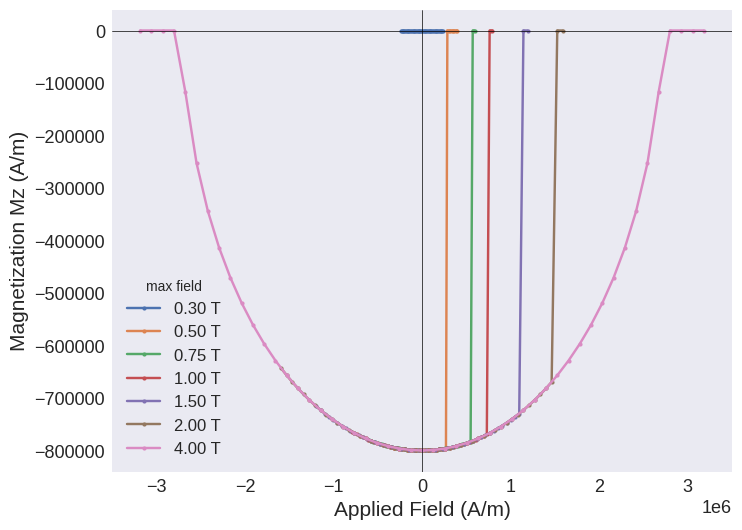

In [35]:
Bmax_values = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]  # Tesla

plt.figure(figsize=(8, 6))
for Bmax in Bmax_values:
    Hmax = (Bmax * u.T).to("A/m").value
    H, Hx, Hy, Hz, mx, my, mz = run_loop(K=1e6, u_axis=[1, 0, 0], H_axis=[0, 0, 1], Hmax=Hmax)
    try:
        Hc, squareness = metrics(H, mz)  # Polar MOKE
        print(f"Bmax = {Bmax:.2f} T  ->  Hc = {Hc:.3e}, squareness = {squareness:.2f}  (detected hard)")
    except ValueError:
        print(f"Bmax = {Bmax:.2f} T  ->  no switching: FALSE NEGATIVE")
    plt.plot(H, mx, marker="o", ms=3, label=f"{Bmax:.2f} T")

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")
plt.legend(title="max field")

Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:56:17]... (10.4 s)
Bmax = 0.30 T  ->  Hc = 8.234e-07 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:56:27]... (12.2 s)
Bmax = 0.50 T  ->  Hc = 3.964e-04 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:56:39]... (15.7 s)
Bmax = 0.75 T  ->  Hc = 2.062e-05 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:56:55]... (16.3 s)
Bmax = 1.00 T  ->  Hc = 1.832e+03 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:57:11]... (14.9 s)
Bmax = 1.50 T  ->  Hc = 1.831e+03 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:57:26]... (27.6 s)
Bmax = 2.00 T  ->  Hc = 1.159e-04 A / m, squareness = 0.00  (detected hard)
Running OOMMF (ExeOOMMFRunner)[2026-06-25T17:57:54]... (6.5 s)
Bmax = 4.00 T  ->  Hc = 2.345e-03 A / m, squareness = 0.00  (detected hard)


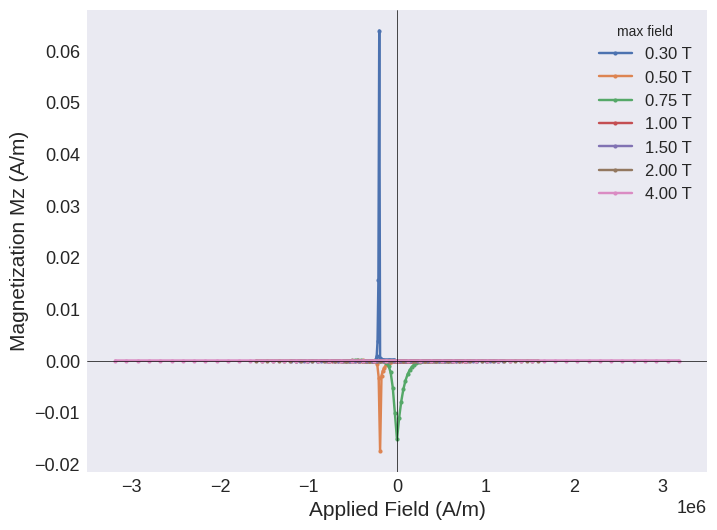

In [36]:
Bmax_values = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]  # Tesla

plt.figure(figsize=(8, 6))
for Bmax in Bmax_values:
    Hmax = (Bmax * u.T).to("A/m").value
    H, Hx, Hy, Hz, mx, my, mz = run_loop(K=0, u_axis=[1, 0, 0], H_axis=[0, 0, 1], Hmax=Hmax)
    try:
        Hc, squareness = metrics(H, mz)  # Polar MOKE
        print(f"Bmax = {Bmax:.2f} T  ->  Hc = {Hc:.3e}, squareness = {squareness:.2f}  (detected hard)")
    except ValueError:
        print(f"Bmax = {Bmax:.2f} T  ->  no switching: FALSE NEGATIVE")
    plt.plot(H, mx, marker="o", ms=3, label=f"{Bmax:.2f} T")

plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Applied Field (A/m)")
plt.ylabel("Magnetization Mz (A/m)")
plt.legend(title="max field")